# Plot detected objects on an OpenStreetMap basemap

Interactive counterpart to `src/plot_clusters_on_map.py`: loads the cluster summary CSV produced by `src/cluster_objects.py` (local, sensor-centered coordinates), georeferences each cluster's centroid and bounding box using the sensor's GPS position/heading (same UTM math as `src/georeference_point_cloud.py`), and plots them over an OSM basemap.

The point of using a notebook instead of the CLI script here: calibrating `heading`/`heading_offset` against real map imagery is iterative -- tweak the parameters cell below and re-run from there to see the result immediately, without a full CLI round-trip and re-opening a saved PNG each time.

**Requires internet access** to fetch OSM tiles (via `contextily`).

In [17]:
%matplotlib inline
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import contextily as ctx
from pyproj import Transformer

from lidar_io import read_ply_xyzi
from georeference_point_cloud import utm_epsg_for, rotate_to_utm
from plot_clusters_on_map import read_clusters_csv

## Parameters

Tweak these and re-run the cells below -- in particular `heading_offset` is the one you'll typically calibrate by eye against the basemap.

In [26]:
CLUSTERING_METHOD = 'dbscan'
# CLUSTERING_METHOD = 'hdbscan'
# CLUSTERING_METHOD = 'euclidean'
# CLUSTERING_METHOD = 'cc'

In [27]:
clusters_csv = f"../outputs/{CLUSTERING_METHOD}_detected_objects.csv"
point_cloud_path = "../outputs/point_cloud.ply"  # set to None to skip the context scatter

# confirmed real capture parameters for this dataset (see REPORT.md)
lat = 37.430785059983215
lon = 24.941538092360716
heading = 280.0
heading_offset = 0.0

basemap_style = "OpenStreetMap.Mapnik"
max_context_points = 100_000

## Load clusters and compute the sensor's UTM position

In [28]:
clusters = read_clusters_csv(clusters_csv)
print(f"Loaded {len(clusters)} clusters from {clusters_csv}")

epsg = utm_epsg_for(lon, lat)
transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True)
sensor_easting, sensor_northing = transformer.transform(lon, lat)
heading_used = (heading + heading_offset) % 360.0

print(f"Sensor UTM position: ({sensor_easting:.2f}, {sensor_northing:.2f}), EPSG:{epsg}")
print(f"Using heading = {heading_used} deg")

Loaded 174 clusters from ../outputs/dbscan_detected_objects.csv
Sensor UTM position: (317874.26, 4144651.48), EPSG:32635
Using heading = 280.0 deg


## Render the map inline

Re-run this cell after changing a parameter above to see the effect immediately.

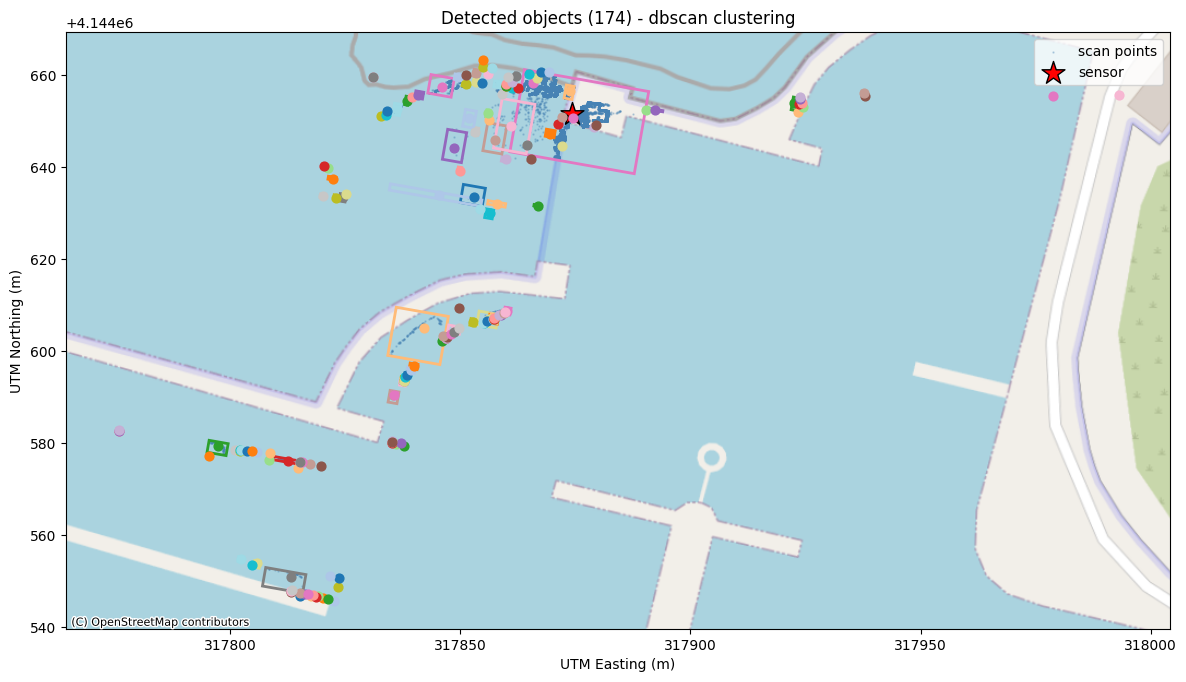

In [29]:
fig, ax = plt.subplots(figsize=(12, 12))

# optional background context: the full local point cloud, georeferenced too
if point_cloud_path:
    context_cloud = read_ply_xyzi(point_cloud_path)
    if len(context_cloud) > max_context_points:
        idx = np.random.choice(len(context_cloud), size=max_context_points, replace=False)
        context_cloud = context_cloud[idx]
    ce, cn = rotate_to_utm(context_cloud[:, 0], context_cloud[:, 1], sensor_easting, sensor_northing, heading_used)
    ax.scatter(ce, cn, s=0.5, c="steelblue", alpha=0.3, zorder=2, label="scan points")

# sensor position marker
ax.scatter([sensor_easting], [sensor_northing], marker="*", s=300, c="red", edgecolor="black",
           zorder=4, label="sensor")

# clusters: bounding box (rotated) + centroid + label
cmap = plt.get_cmap("tab20")
for i, c in enumerate(clusters):
    color = cmap(i % 20)

    corners_x = np.array([c["min_x"], c["max_x"], c["max_x"], c["min_x"]])
    corners_y = np.array([c["min_y"], c["min_y"], c["max_y"], c["max_y"]])
    corners_e, corners_n = rotate_to_utm(corners_x, corners_y, sensor_easting, sensor_northing, heading_used)

    polygon = Polygon(np.column_stack([corners_e, corners_n]), fill=False,
                       edgecolor=color, linewidth=2, zorder=3)
    ax.add_patch(polygon)

    centroid_e, centroid_n = rotate_to_utm(c["centroid_x"], c["centroid_y"], sensor_easting, sensor_northing, heading_used)
    ax.scatter([centroid_e], [centroid_n], s=40, color=color, zorder=4)
    # ax.annotate(f"#{c['cluster_id']} ({c['n_points']}pts)", (centroid_e, centroid_n),
    #             fontsize=9, color=color, fontweight="bold", zorder=5,
    #             xytext=(5, 5), textcoords="offset points")

ax.set_aspect("equal")

provider = ctx.providers
for part in basemap_style.split("."):
    provider = provider[part]
ctx.add_basemap(ax, crs=f"EPSG:{epsg}", source=provider, zorder=1)

ax.set_xlabel("UTM Easting (m)")
ax.set_ylabel("UTM Northing (m)")
ax.set_title(f"Detected objects ({len(clusters)}) - {CLUSTERING_METHOD} clustering")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## Optional: save the figure once you're happy with it

In [31]:
fig.savefig(f"../outputs/{CLUSTERING_METHOD}_clusters_map.png", dpi=150)
print(f"Saved ../outputs/{CLUSTERING_METHOD}_clusters_map.png")

Saved ../outputs/cc_clusters_map.png


## Interactive track viewer (frame slider, georeferenced)

`outputs/tracks_plot.png` (all ~58 tracks overlaid on one static image, most of
them static and relabeled on top of each other) is hard to read. This is a
georeferenced, frame-by-frame alternative: drag the slider to move through
rotations one at a time, see just that frame's detections on the OSM
basemap, with an optional trail showing where each *moving* track has been
(static tracks are muted gray and untrailed, since there are dozens of them
and they don't go anywhere).

Reuses `sensor_easting`, `sensor_northing`, `heading_used`, `epsg`, and
`basemap_style` from the cells above -- run those first.

In [30]:
import csv
from ipywidgets import interact, IntSlider, Checkbox

tracks_per_frame_csv = "../outputs/tracks_per_frame.csv"
tracks_summary_csv = "../outputs/tracks_summary.csv"


def read_tracks_per_frame(path):
    rows = []
    with open(path, newline="") as f:
        for row in csv.DictReader(f):
            rows.append({
                "frame": int(float(row["frame"])),
                "track_id": int(row["track_id"]),
                "centroid_x": float(row["centroid_x"]),
                "centroid_y": float(row["centroid_y"]),
                "n_points": int(row["n_points"]),
            })
    return rows


def read_track_classification(path):
    classification = {}
    with open(path, newline="") as f:
        for row in csv.DictReader(f):
            classification[int(row["track_id"])] = row["classification"]
    return classification


track_rows = read_tracks_per_frame(tracks_per_frame_csv)
track_classification = read_track_classification(tracks_summary_csv)
frames_available = sorted(set(r["frame"] for r in track_rows))
print(f"Loaded {len(track_rows)} per-frame detections across {len(frames_available)} frames "
      f"({frames_available[0]}-{frames_available[-1]}), {len(track_classification)} tracks "
      f"({sum(1 for c in track_classification.values() if c == 'moving')} moving)")

Loaded 204926 per-frame detections across 4637 frames (0-4636), 5847 tracks (1030 moving)


In [31]:
xs = np.array([r["centroid_x"] for r in track_rows])
ys = np.array([r["centroid_y"] for r in track_rows])
utm_e, utm_n = rotate_to_utm(xs, ys, sensor_easting, sensor_northing, heading_used)
for r, e, n in zip(track_rows, utm_e, utm_n):
    r["utm_e"], r["utm_n"] = e, n

rows_by_frame = {}
for r in track_rows:
    rows_by_frame.setdefault(r["frame"], []).append(r)

rows_by_track = {}
for r in track_rows:
    rows_by_track.setdefault(r["track_id"], []).append(r)
for rows in rows_by_track.values():
    rows.sort(key=lambda r: r["frame"])

# fixed extent across all frames, so the basemap tiles/zoom stay constant as the slider moves
# (contextily caches tiles to disk, so repeated add_basemap calls over the same extent are fast
# after the first one -- no need to prefetch a single static image by hand)
margin = 10.0
map_west, map_east = utm_e.min() - margin, utm_e.max() + margin
map_south, map_north = utm_n.min() - margin, utm_n.max() + margin

In [ ]:
_provider = ctx.providers
for _part in basemap_style.split("."):
    _provider = _provider[_part]
_cmap = plt.get_cmap("tab20")
_map_zoom = 19  # pinned (rather than "auto") -- this extent can push contextily's auto-zoom past the provider's max


def plot_tracks_frame(frame, show_trail=True):
    fig, ax = plt.subplots(figsize=(9, 9))

    if show_trail:
        for track_id, rows in rows_by_track.items():
            if track_classification.get(track_id) != "moving":
                continue
            trail = [r for r in rows if r["frame"] <= frame]
            if len(trail) > 1:
                ax.plot([r["utm_e"] for r in trail], [r["utm_n"] for r in trail],
                        "-", color=_cmap(track_id % 20), linewidth=1.5, alpha=0.6, zorder=3)

    for r in rows_by_frame.get(frame, []):
        track_id = r["track_id"]
        is_moving = track_classification.get(track_id) == "moving"
        color = _cmap(track_id % 20) if is_moving else "lightgray"
        ax.scatter(r["utm_e"], r["utm_n"], color=color, s=70 if is_moving else 30,
                   edgecolor="black" if is_moving else "none", linewidth=1, zorder=5)
        # if is_moving:
        #     ax.annotate(f"#{track_id}", (r["utm_e"], r["utm_n"]), fontsize=9, fontweight="bold",
        #                 color=color, xytext=(5, 5), textcoords="offset points", zorder=6)

    ax.set_xlim(map_west, map_east)
    ax.set_ylim(map_south, map_north)
    ax.set_aspect("equal")
    ctx.add_basemap(ax, crs=f"EPSG:{epsg}", source=_provider, zoom=_map_zoom, zorder=1)

    n_here = len(rows_by_frame.get(frame, []))
    ax.set_xlabel("UTM Easting (m)")
    ax.set_ylabel("UTM Northing (m)")
    ax.set_title(f"Frame {frame} ({frame + 1}/{len(frames_available)}) -- {n_here} detections\n"
                 f"gray = static, colored = moving" + (" (trail shown)" if show_trail else ""))
    fig.tight_layout()
    plt.show()


interact(
    plot_tracks_frame,
    frame=IntSlider(min=frames_available[0], max=frames_available[-1], step=1,
                    value=frames_available[0], continuous_update=False, description="Frame"),
    show_trail=Checkbox(value=True, description="Show moving-object trails"),
)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame', max=4636), Checkbox(val…

<function __main__.plot_tracks_frame(frame, show_trail=True)>